# Graphs and Spatial Models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/kernellib/blob/main/docs/notebooks/graphs_and_spatial.ipynb)

Spatial data come on graphs: the pixels of a raster form a lattice, scattered sensors form a nearest-neighbour or proximity graph, and areal units form a contiguity graph. kernellib stores all of them as sparse `Graph` / `GridGraph` objects whose Laplacians are gaussx operators, and builds spatial models on their spectra. This notebook tours the pieces at the scale each one is meant for, with the mathematics, a pseudocode summary of each pipeline, and a note on the numerics of each step.

**What you'll learn:**

1. The three graph Laplacians, why a raster's lattice graph has closed-form, Kronecker-structured Laplacian eigenpairs, and how to get them for a million-pixel grid with `laplacian_eigpairs`.
2. How to draw graph Matérn prior samples on a k-NN graph of scattered points, from `matern_graph_kernel` or directly from the Laplacian spectrum, what $\nu$ and the lengthscale do, and how much variance a truncated prior keeps.
3. How to build parameter-free proximity graphs (Delaunay, Gabriel, relative neighbourhood) on irregular sites, and an ICAR / Besag prior on them with `structure_matrix` and `graph_null_space`, including the BYM2 scaling and the link to SPDE priors on meshes.
4. Where to go for spatial-spectral embeddings of images.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "kernellib @ git+https://github.com/jejjohnson/kernellib@main",
        ],
        check=True,
    )

In [2]:
import importlib.util
import logging
import time
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import einx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

import kernellib as kl
from kernellib.functional import graph_matern_spectrum


jax.config.update("jax_enable_x64", True)

In [3]:
try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p jax,gaussx,matplotlib,kernellib")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.17.1

jax       : 0.11.2
gaussx    : 0.6.1
matplotlib: 3.11.2
kernellib : 0.0.17

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. A raster as a grid graph

### Graph Laplacians

A weighted, undirected graph on $N$ nodes is its symmetric adjacency matrix $W \in \mathbb R^{N \times N}$ ($W_{ij} \ge 0$, zero diagonal), with degree matrix $D = \operatorname{diag}(W\mathbf 1)$. kernellib uses three Laplacians {cite:p}`vonluxburg2007tutorial`:

$$L = D - W, \qquad L_{\mathrm{sym}} = I - D^{-1/2} W D^{-1/2}, \qquad L_{\mathrm{rw}} = I - D^{-1} W.$$

The unnormalised Laplacian is the quadratic form of the graph differences,

$$f^\top L f = \sum_{\{i, j\} \in E} W_{ij}\,(f_i - f_j)^2 \;\ge\; 0,$$

summed over the edges, each once. So $L$ is positive semidefinite, and its null space is spanned by the indicator vectors of the connected components. $L_{\mathrm{sym}}$ is symmetric with eigenvalues in $[0, 2]$. $L_{\mathrm{rw}} = D^{-1/2} L_{\mathrm{sym}} D^{1/2}$ has the same eigenvalues, and its eigenvectors $y = D^{-1/2} u$ solve the generalised problem $L y = \lambda D y$ that the eigenmaps use. `graph_laplacian(W, normalization)` returns any of the three as a dense matrix; a `Graph` or `GridGraph` gives $L$ as a sparse operator (`laplacian_operator()`), and `laplacian_eigpairs(graph, n, normalization=...)` takes `"unnormalized"` ($L$) or `"symmetric"` ($L_{\mathrm{sym}}$).

### A grid graph is a Kronecker sum

A raster of shape $H \times W$ is a lattice: `grid_graph((H, W))` joins every pixel to its 4 face neighbours and numbers the pixels in row-major order, so that `einx.id("h w -> (h w)", image)` is the matching vector. A `GridGraph` never stores its edges. With face connectivity its Laplacian is the **Kronecker sum** of two path Laplacians,

$$L = L_H \oplus L_W = L_H \otimes I_W + I_H \otimes L_W,$$

where $L_n$ is the Laplacian of a path of $n$ nodes: tridiagonal, with diagonal $(1, 2, \dots, 2, 1)$ and $-1$ off the diagonal. Its eigenpairs are known in closed form; the eigenvectors are the DCT-II basis {cite:p}`strang1999dct`:

$$\lambda_k = 2 - 2\cos\frac{\pi k}{n} = 4\sin^2\frac{\pi k}{2n}, \qquad u_k[i] \propto \cos\frac{\pi k\,(i + \tfrac12)}{n}, \qquad k, i = 0, \dots, n - 1.$$

Kronecker sums add eigenvalues and multiply eigenvectors,

$$(L_H \oplus L_W)\,(u_a \otimes v_b) = (\lambda_a + \mu_b)\,(u_a \otimes v_b),$$

so all $HW$ eigenpairs of the grid come from the $H + W$ eigenpairs of the factors. The $m$ smallest need only a sort of the $HW$ sums, and their eigenvectors are outer products: $O(HW \log HW)$ time for the sort and $O(m\,HW)$ for the eigenvectors, against the $O((HW)^3)$ of a dense eigendecomposition.

### What kernellib does

`laplacian_eigpairs` picks `method="kronecker"` for a face-connected `GridGraph` with `normalization="unnormalized"`, and runs no eigensolver. It evaluates each factor's eigenvalues from the closed form, written as $4\sin^2(\pi k / 2n)$, which does not cancel at small $k$, and multiplies them by the axis weight ($1/h^2$ for a grid `spacing` $h$). A periodic axis (`periodic=True`) is a cycle instead of a path: $\lambda_k = 4\sin^2(\pi m / n)$ with $m = \min(k, n - k)$, and real Fourier modes (cosines and sines) as eigenvectors. The $HW$ eigenvalue sums are sorted, and only the $m$ selected columns of each factor's DCT-II (or Fourier) basis are built, so the cost is $O(n)$ per axis for the eigenvalues, the sort of the sums, and $O(m\,HW)$ for the outer products. Before kernellib 0.0.17 this path ran a dense `eigh` of each factor instead, $O(n^3)$ per axis ([#156](https://github.com/jejjohnson/kernellib/issues/156)).

### Pipeline

```text
input: raster shape (H, W); number of eigenpairs m
1. λᴴ_a ← 4 sin²(πa / 2H), a < H              # path Laplacian L_H, closed form
2. λᵂ_b ← 4 sin²(πb / 2W), b < W              # path Laplacian L_W
3. s ← [λᴴ_a + λᵂ_b for a < H, b < W], flattened row-major   # HW sums
4. idx ← argsort(s)[:m];  (a_j, b_j) ← unravel(idx_j, (H, W))
5. uᴴ_j[h] ← c(a_j, H) cos(π a_j (h + ½) / H)   # DCT-II columns, only the m selected
   uᵂ_j[w] ← c(b_j, W) cos(π b_j (w + ½) / W)   # c(0, n) = √(1/n), c(k, n) = √(2/n)
6. Λ ← s[idx];  U[:, j] ← uᴴ_j ⊗ uᵂ_j          # node (h, w) ↦ h·W + w
return Λ (m,), U (HW, m)
```

In kernellib this is `lam, U = kl.laplacian_eigpairs(kl.grid_graph((H, W)), m)`.

The synthetic raster below has $1000 \times 1000 = 10^6$ pixels: a smooth field plus a sharp-edged disc plus noise.

In [4]:
n_side = 1000
yy, xx = np.mgrid[0:n_side, 0:n_side] / n_side
smooth = np.sin(3 * np.pi * xx) * np.cos(2 * np.pi * yy)
disc = ((xx - 0.65) ** 2 + (yy - 0.35) ** 2 < 0.15**2).astype(float)
noise = 0.3 * np.random.default_rng(0).normal(size=(n_side, n_side))
raster = jnp.asarray(smooth + disc + noise)

grid = kl.grid_graph(raster.shape)
print(f"{type(grid).__name__} with {grid.n_nodes:,} nodes")
print(f"Laplacian operator: {type(grid.laplacian_operator()).__name__}")

GridGraph with 1,000,000 nodes


Laplacian operator: KroneckerSum


Timing the 16 smallest eigenpairs, after a warm-up call so that JAX's compilation is not counted, and, for comparison, one dense `eigh` of a 1000-node path Laplacian, the step the closed form replaces:

In [5]:
n_eig = 16
lam, U = kl.laplacian_eigpairs(grid, n_eig)  # warm-up
U.block_until_ready()

start = time.perf_counter()
lam, U = kl.laplacian_eigpairs(grid, n_eig)
U.block_until_ready()
t_grid = time.perf_counter() - start

path = kl.grid_graph((n_side,)).laplacian_operator().as_matrix()
start = time.perf_counter()
jnp.linalg.eigh(path)[1].block_until_ready()
t_path = time.perf_counter() - start

print(f"{n_eig} eigenpairs of the 10^6-node grid: {t_grid:.1f} s")
print(f"one dense eigh of a {n_side}-node path Laplacian: {t_path:.1f} s")
print(f"eigenvector matrix: {U.shape}, {U.nbytes / 1e6:.0f} MB")

16 eigenpairs of the 10^6-node grid: 0.3 s
one dense eigh of a 1000-node path Laplacian: 0.3 s
eigenvector matrix: (1000000, 16), 128 MB


Nothing of size $N \times N$ was formed (a dense Laplacian would take 8 TB in float64), and no eigensolver ran: the time is the sort of the $10^6$ eigenvalue sums and the outer products that fill the 128 MB eigenvector matrix. Before kernellib 0.0.17 the Kronecker path also ran a dense `eigh` of each factor, the second timing above, twice per call ([#156](https://github.com/jejjohnson/kernellib/issues/156)); one of them alone takes about as long as the whole closed-form call. The eigenvalues are the closed-form sums; `laplacian_eigpairs` evaluates the same expression, so they match to the last bit:

In [6]:
k = jnp.arange(n_side)
path_lam = 4 * jnp.sin(jnp.pi * k / (2 * n_side)) ** 2
sums = einx.add("a, b -> (a b)", path_lam, path_lam)
closed_form = jnp.sort(sums)[:n_eig]
print("first eigenvalues:", np.round(np.asarray(lam[:6]), 7))
rel_err = jnp.max(jnp.abs(lam[1:] - closed_form[1:]) / closed_form[1:])
print(f"max relative error vs 4 sin^2(pi k / 2n) sums: {float(rel_err):.1e}")

first eigenvalues: [0.00e+00 9.90e-06 9.90e-06 1.97e-05 3.95e-05 3.95e-05]


max relative error vs 4 sin^2(pi k / 2n) sums: 0.0e+00


**Numerics: float32 against float64.** The smallest non-zero eigenvalue of a 1000-node path is $\lambda_1 = 4\sin^2(\pi / 2000) \approx 9.9 \times 10^{-6}$. A dense symmetric eigensolver has backward error about $\varepsilon \|L_n\|_2$ with $\|L_n\|_2 < 4$, so each eigenvalue it computes carries an absolute error of order $\varepsilon$. With $\varepsilon \approx 2.2 \times 10^{-16}$ (float64) that is harmless; with $\varepsilon \approx 1.2 \times 10^{-7}$ (float32) the error is a few percent of $\lambda_1$. The closed form has no such floor: $4\sin^2(\pi k / 2n)$ has relative error of order $\varepsilon$ for every $k$ (the equivalent $2 - 2\cos(\pi k / n)$ would cancel catastrophically for small $k$), and the eigenvector phases are reduced modulo their period in integer arithmetic. The next cell compares a float32 dense `eigh` of the path factor with a float32 run of `laplacian_eigpairs`, on a grid whose float32 `spacing` makes its weights, and so its eigenpairs, float32.

In [7]:
lam32 = jnp.linalg.eigh(path.astype(jnp.float32))[0]
sums32 = jnp.sort(einx.add("a, b -> (a b)", lam32, lam32))[:n_eig]
rel_err_eigh = jnp.max(jnp.abs(sums32[1:] - closed_form[1:]) / closed_form[1:])

grid32 = kl.grid_graph(raster.shape, spacing=jnp.ones(2, dtype=jnp.float32))
lam_cf32, _ = kl.laplacian_eigpairs(grid32, n_eig)
rel_err_cf32 = jnp.max(jnp.abs(lam_cf32[1:] - closed_form[1:]) / closed_form[1:])

errors = {
    "float32, dense eigh of each factor": rel_err_eigh,
    f"float32, laplacian_eigpairs ({lam_cf32.dtype})": rel_err_cf32,
    "float64, laplacian_eigpairs": rel_err,
}
for name, err in errors.items():
    print(f"max relative error, {name:<38} {float(err):.1e}")

max relative error, float32, dense eigh of each factor     6.3e-02
max relative error, float32, laplacian_eigpairs (float32)  9.2e-08
max relative error, float64, laplacian_eigpairs            0.0e+00


A float32 dense `eigh` of the factors misses the 15 non-zero eigenvalues by up to about 6% ($6.3 \times 10^{-2}$); issue [#156](https://github.com/jejjohnson/kernellib/issues/156) recorded 6.5% for a float32 run of `laplacian_eigpairs` on this grid when the Kronecker path still called `eigh`. The closed form in float32 is accurate to $9.2 \times 10^{-8}$, float32's own precision, and in float64 it reproduces the reference exactly. The smooth end of the spectrum is exactly what spectral methods use (low-pass filters, truncated priors, eigenmaps), and on a face-connected grid float32 now resolves it. Graphs without a closed form still go through an eigensolver, with the absolute-error floor above, so keep x64 on for their spectra, as this notebook does.

The eigenvectors are products of cosines along each axis, $u_i \otimes v_j$. The first is the constant vector. On a square grid $\lambda_i + \mu_j = \lambda_j + \mu_i$, so most eigenvalues come in pairs whose eigenvectors are the same pattern rotated by 90°; within a repeated eigenvalue only the eigenspace is unique, and another solver could return any rotation of the pair.

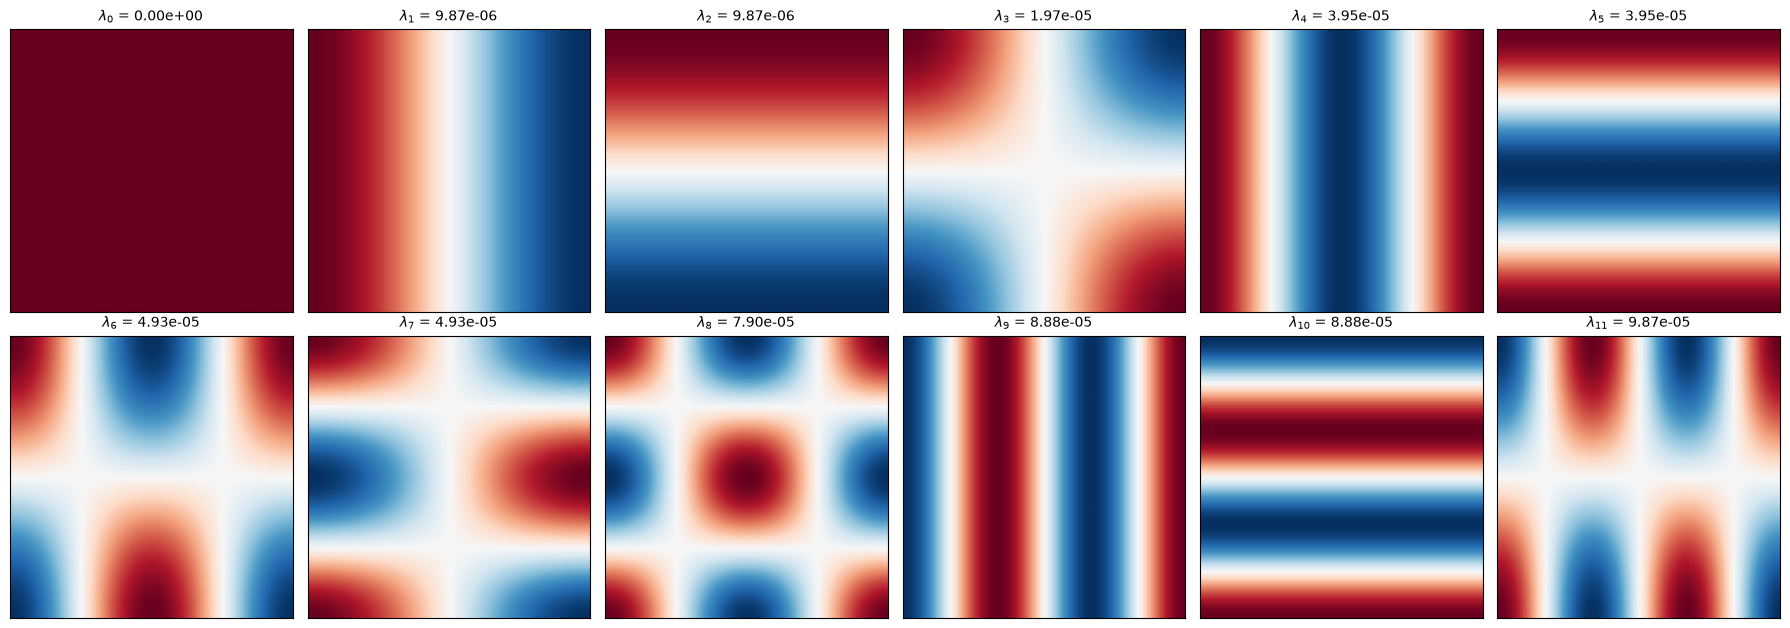

In [8]:
images = einx.id("(h w) n -> n h w", U, h=n_side)
fig, axes = plt.subplots(2, 6, figsize=(18, 6.4))
for j, ax in enumerate(axes.flat):
    vmax = float(jnp.max(jnp.abs(images[j])))
    ax.imshow(images[j, ::8, ::8], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"$\\lambda_{{{j}}}$ = {float(lam[j]):.2e}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

These eigenvectors are the graph's Fourier basis, ordered from smooth to rough: the graph Fourier transform of a signal $f$ is $\hat f = U^\top f$, and keeping the first $m$ coefficients gives the low-pass projection $f_m = U_m U_m^\top f$. Projecting the raster onto the first 16 is such a filter on the lattice. The Dirichlet energy $f^\top L f = \sum_{i \sim j} (f_i - f_j)^2$ (`GridGraph.dirichlet_energy`, unit edge weights here) measures roughness without forming $L$:

Dirichlet energy: raster 3.616e+05, 16-mode projection 1.698e+01


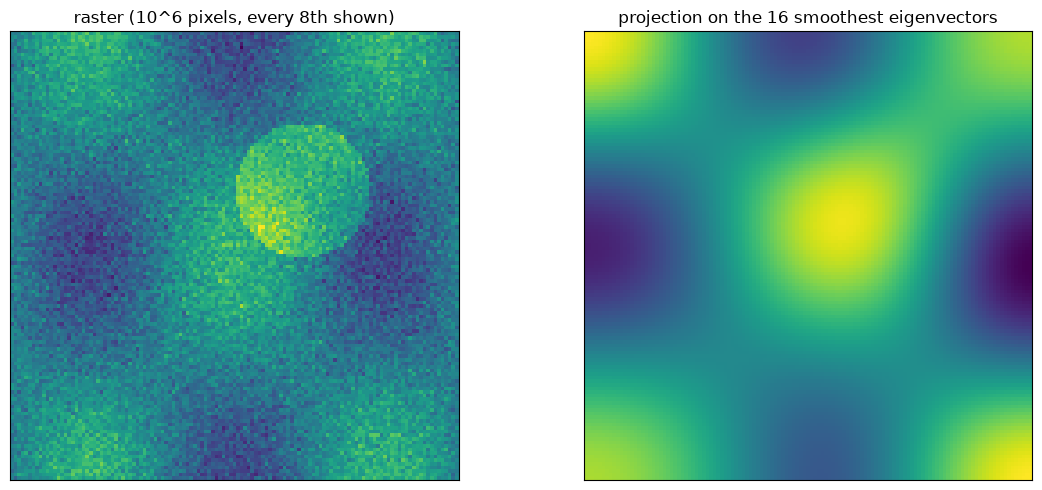

In [9]:
f = einx.id("h w -> (h w)", raster)
coef = einx.dot("n m, n -> m", U, f)
low_pass = einx.id("(h w) -> h w", U @ coef, h=n_side)

energy_raw = float(grid.dirichlet_energy(f))
energy_smooth = float(grid.dirichlet_energy(einx.id("h w -> (h w)", low_pass)))
print(
    f"Dirichlet energy: raster {energy_raw:.3e}, 16-mode projection {energy_smooth:.3e}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(raster[::8, ::8], cmap="viridis")
axes[0].set_title("raster (10^6 pixels, every 8th shown)")
axes[1].imshow(low_pass[::8, ::8], cmap="viridis")
axes[1].set_title("projection on the 16 smoothest eigenvectors")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## 2. Graph Matérn priors on a k-NN graph

On scattered points there is no lattice, but a k-NN graph gives a geometry that follows the data: distances are measured *along the graph*. `knn_graph(X, k)` joins each point to its $k$ nearest neighbours, symmetrises the edge set, and uses heat weights $W_{ij} = \exp(-\|x_i - x_j\|^2 / 2\sigma^2)$, with $\sigma$ the median neighbour distance; `ensure_connected=True` adds bridging edges until the graph is connected.

### Spectral graph kernels

A spectral graph kernel {cite:p}`smola2003graphkernels` is a function of the Laplacian. With the eigendecomposition $L = U \Lambda U^\top$ (kernellib's graph kernels use $L_{\mathrm{sym}}$ by default, so $\lambda \in [0, 2]$),

$$K = U\, \Phi(\Lambda)\, U^\top, \qquad \Phi \ge 0 \text{ decreasing}.$$

A prior $f \sim \mathcal N(0, K)$ penalises $f^\top K^{-1} f = \sum_k \hat f_k^2 / \Phi(\lambda_k)$: rough eigenvectors (large $\lambda$) get small prior variance. Two choices of $\Phi$:

- **Diffusion (heat) kernel** {cite:p}`kondor2002diffusion`: $K = e^{-\beta L}$, $\Phi(\lambda) = e^{-\beta\lambda}$, heat diffusing along the graph for time $\beta$ (`diffusion_kernel(W, beta)`, unnormalised; the spectrum alone is `kernellib.functional.graph_heat_spectrum` with $\beta = \ell^2/2$).
- **Graph Matérn kernel** {cite:p}`borovitskiy2021graphmatern`, in kernellib's parametrisation (`kernellib.functional.graph_matern_spectrum`):

$$\Phi(\lambda) = c \left(\frac{2\nu}{\ell^2} + \lambda\right)^{-\nu}, \qquad c \text{ such that } \frac1N \operatorname{tr} K = \frac1N \sum_{k=1}^{N} \Phi(\lambda_k) = \sigma^2.$$

It is the covariance of the graph SPDE $(\kappa^2 + L)^{\nu/2} f = \mathcal W$ with $\kappa^2 = 2\nu/\ell^2$ and white noise $\mathcal W$. On a graph $\nu$ is the SPDE exponent itself: no dimension enters it, unlike the Euclidean $\nu = \alpha - d/2$. $\nu$ sets smoothness and $\ell$ the correlation range, in the units of the Laplacian's eigenvalues; as $\nu \to \infty$, $\Phi$ tends to the heat spectrum with $\beta = \ell^2/2$. `matern_graph_kernel(W, nu=ν, lengthscale=ℓ, variance=σ²)` returns the dense $N \times N$ kernel.

### Truncation and sampling

For a large graph one keeps the $m$ smallest eigenpairs, $K_m = U_m \Phi_m U_m^\top$. The fraction of the prior variance this keeps is

$$v(m) = \frac{\operatorname{tr} K_m}{\operatorname{tr} K} = \frac{\sum_{k \le m} \Phi(\lambda_k)}{\sum_{k \le N} \Phi(\lambda_k)}.$$

`graph_matern_spectrum(lam, ..., n_nodes=N)` normalises whatever eigenvalues it is given: passed only the $m$ smallest, it rescales them so that $\sum_{k \le m} \Phi_k = N \sigma^2$, and the truncated prior keeps average variance $\sigma^2$ by inflating the modes it keeps. The $v(m)$ printed below uses the full spectrum, to measure what a truncation drops. A prior sample is

$$f = U_m\, \Phi_m^{1/2}\, z, \qquad z \sim \mathcal N(0, I_m),$$

at $O(Nm)$ cost once the eigenpairs are known; with $m = N$ it is exact.

### Pipeline

```text
input: points X (N, d); k; ν, ℓ; number of eigenpairs m
1. G ← knn_graph(X, k, ensure_connected=True)     # sparse; heat weights
2. (λ, U) ← laplacian_eigpairs(G, m, normalization="symmetric")
              # dense eigh up to a few thousand nodes; "lanczos" / "arpack" beyond
3. Φ ← graph_matern_spectrum(λ, nu=ν, lengthscale=ℓ, n_nodes=N)
4. z ~ N(0, I_m)
5. f ← U (√Φ ⊙ z)
return f (N,)
```

The points below fill a horseshoe. Two points on either side of the gap are close in the plane but far apart along the graph.

In [10]:
rng = np.random.default_rng(0)
n_pts = 1500
theta = rng.uniform(0.15 * np.pi, 1.85 * np.pi, n_pts)
radius = np.sqrt(rng.uniform(0.5**2, 1.0**2, n_pts))
pts = jnp.asarray(np.column_stack([radius * np.cos(theta), radius * np.sin(theta)]))

knn = kl.knn_graph(pts, 8, ensure_connected=True)
print(
    f"k-NN graph: {knn.n_nodes} nodes, {knn.topology.n_edges} edges, "
    f"{kl.n_components_graph(knn)} connected component(s)"
)

lam_k, U_k = kl.laplacian_eigpairs(knn, n_pts, normalization="symmetric")
print(f"all {n_pts} eigenpairs (dense); smallest: {np.round(np.asarray(lam_k[:4]), 5)}")

k-NN graph: 1500 nodes, 6978 edges, 1 connected component(s)


all 1500 eigenpairs (dense); smallest: [-0.       0.00021  0.00082  0.00191]


`matern_graph_kernel` returns the dense $N \times N$ kernel. The same kernel comes from the eigenpairs and `graph_matern_spectrum`, $K = U \operatorname{diag}(\Phi) U^\top$, which is also the route to large graphs: there one keeps only the smallest eigenpairs, the truncated rank-$m$ prior above.

In [11]:
K = kl.matern_graph_kernel(knn, nu=1.5, lengthscale=5.0)
phi = graph_matern_spectrum(lam_k, nu=1.5, lengthscale=5.0, n_nodes=n_pts)
K_spec = einx.dot("n m, p m -> n p", einx.multiply("n m, m -> n m", U_k, phi), U_k)
print(f"average marginal variance tr(K)/N = {float(jnp.trace(K)) / n_pts:.4f}")
print(f"max |K - U Phi U^T| = {float(jnp.max(jnp.abs(K - K_spec))):.1e}")
for M in (50, 200):  # a truncated prior keeps the M smallest eigenpairs
    print(
        f"variance kept by the {M} smallest eigenpairs: "
        f"{float(phi[:M].sum() / phi.sum()):.3f}"
    )

average marginal variance tr(K)/N = 1.0000
max |K - U Phi U^T| = 6.0e-15


variance kept by the 50 smallest eigenpairs: 0.335
variance kept by the 200 smallest eigenpairs: 0.616


The two kernels agree to rounding error. For this rough $\nu = 1.5$ prior a truncation needs many modes: the 50 smallest of the 1500 eigenpairs carry about a third of the prior variance and the 200 smallest about 62%.

Prior samples for three smoothness values and two lengthscales, all from the same white noise $z$:

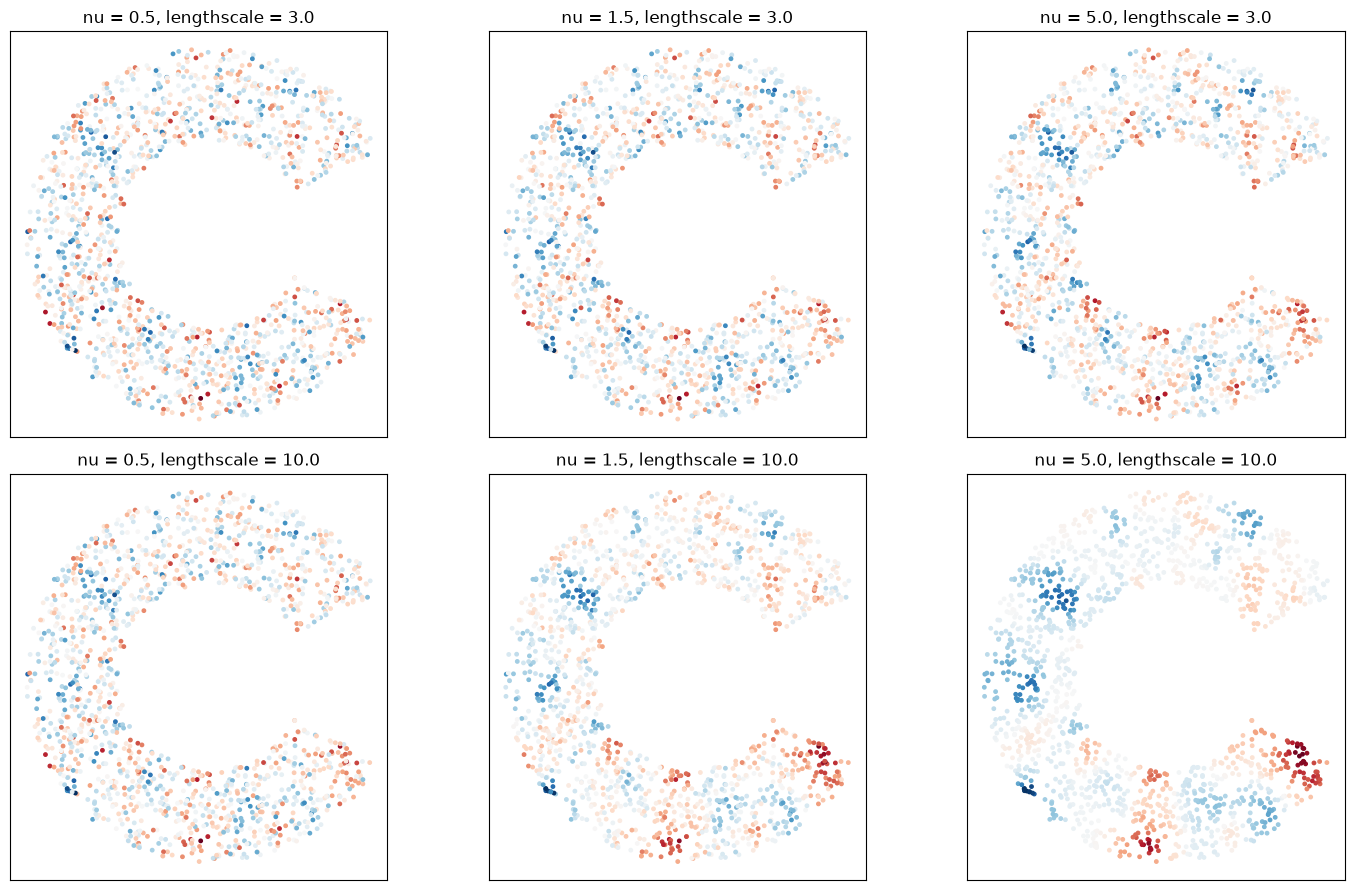

In [12]:
z = jax.random.normal(jax.random.key(0), (n_pts,))
nus = (0.5, 1.5, 5.0)
lengthscales = (3.0, 10.0)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for row, ell in enumerate(lengthscales):
    for col, nu in enumerate(nus):
        phi = graph_matern_spectrum(lam_k, nu=nu, lengthscale=ell, n_nodes=n_pts)
        sample = U_k @ (jnp.sqrt(phi) * z)
        ax = axes[row, col]
        ax.scatter(pts[:, 0], pts[:, 1], c=sample, s=6, cmap="RdBu_r")
        ax.set_title(f"nu = {nu}, lengthscale = {ell}")
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
plt.tight_layout()
plt.show()

With $\nu = 1.5$ and $\nu = 5$, a longer lengthscale gives larger features and a larger $\nu$ gives smoother ones. With $\nu = 0.5$ the samples stay rough at both lengthscales: the spectrum decays so slowly that the high-frequency modes dominate.

The correlation with one node x, at the tip of the lower arm next to the gap, shows the graph geometry. It spreads along the lower arm and never reaches the tip of the upper arm, which is just as close in the plane:

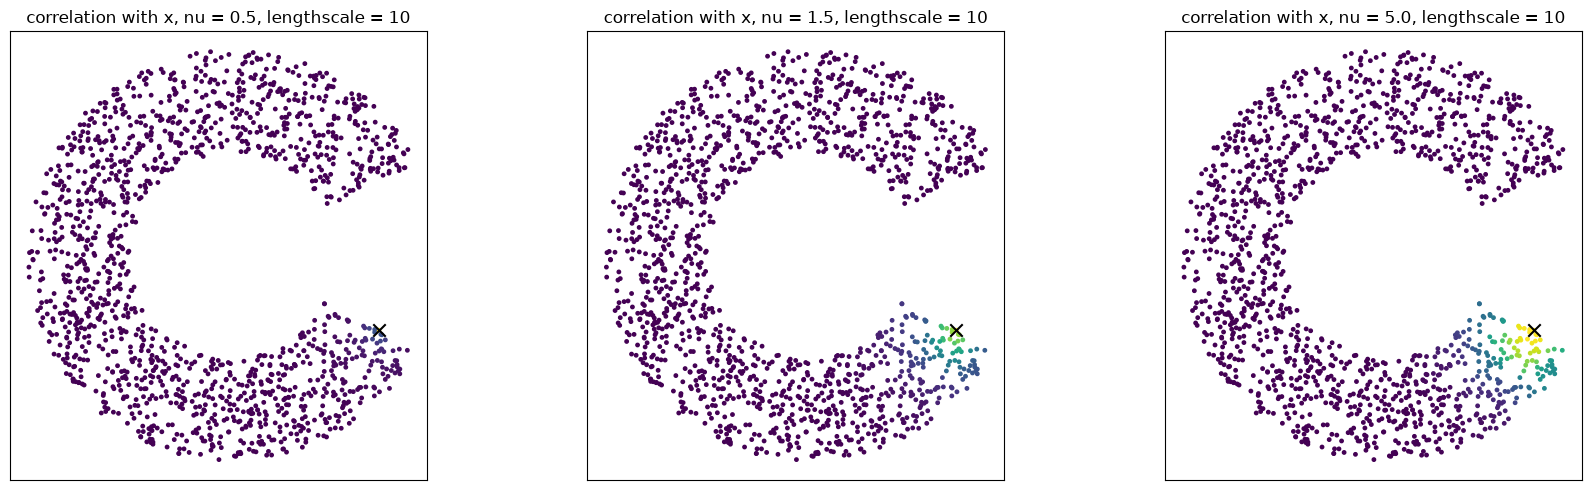

In [13]:
anchor = int(jnp.argmin(jnp.abs(pts[:, 0] - 0.75) + jnp.abs(pts[:, 1] - 0.0)))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, nu in zip(axes, nus, strict=True):
    phi = graph_matern_spectrum(lam_k, nu=nu, lengthscale=10.0, n_nodes=n_pts)
    weighted = einx.multiply("n m, m -> n m", U_k, phi)
    cov = weighted @ U_k[anchor]
    var = einx.sum("n m -> n", weighted * U_k)
    corr = cov / jnp.sqrt(var * cov[anchor])
    ax.scatter(pts[:, 0], pts[:, 1], c=corr, s=6, cmap="viridis", vmin=0, vmax=1)
    ax.scatter(pts[anchor, 0], pts[anchor, 1], c="k", marker="x", s=80)
    ax.set_title(f"correlation with x, nu = {nu}, lengthscale = 10")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

**Numerics.** Here all 1500 eigenpairs come from a dense `eigh` in float64 ($O(N^3)$, fine up to a few thousand nodes). The graph is connected, so exactly one eigenvalue is zero up to rounding (printed as `-0.`); the graph kernels clip eigenvalues at 0 before applying $\Phi$, so a tiny negative one is harmless. The spectrum is evaluated in log space and normalised with a log-sum-exp, so large $\nu$, where $(2\nu/\ell^2 + \lambda)^{-\nu}$ itself underflows, is stable. For a large graph, take the $m$ smallest eigenpairs with `laplacian_eigpairs(..., method="lanczos", key=key)` (JAX, differentiable) or `method="arpack"` (SciPy, CPU). Lanczos converges slowly at the bottom of a graph spectrum, where eigenvalues are small and clustered, so it works in a Krylov space `oversample` (default 200) wider than $m$, and it checks what it returns: every pair must have residual $\|L u - \lambda u\| \le \sqrt{\varepsilon}\, \max(c, 1)$, with $c$ the Gershgorin bound on $\lambda_{\max}$. A run that fails is repeated with the oversample doubled, up to `max_oversample` (default 1600) or until the Krylov space spans the graph, and if the last run still fails, `laplacian_eigpairs` raises a `RuntimeError` instead of returning wrong eigenpairs; under `jit` there is a single run, checked with `equinox.error_if`. When Lanczos raises, use ARPACK. The optional neighbour backends (`knn_graph(..., backend="pynndescent")` or `"sklearn"`) return weights in the dtype of the points, so under x64 the graph is float64 whichever backend builds it.

## 3. Proximity graphs and ICAR priors on irregular sites

### Proximity graphs

For points $x_1, \dots, x_N$ in two or three dimensions there are graphs with no $k$ to tune. With $d_{ij} = \|x_i - x_j\|$:

- **Delaunay graph (DT):** $\{i, j\}$ is an edge when some circle (sphere in 3-D) through $x_i$ and $x_j$ has no other point inside: the edges of the Delaunay triangulation.
- **Gabriel graph (GG)** {cite:p}`gabriel1969gabriel`: $\{i, j\}$ is an edge when the closed disc with diameter $x_i x_j$ contains no other point, $d_{ik}^2 + d_{jk}^2 \ge d_{ij}^2$ for all $k$.
- **Relative neighbourhood graph (RNG)** {cite:p}`toussaint1980rng`: $\{i, j\}$ is an edge when no point is closer to both ends than they are to each other, $\max(d_{ik}, d_{jk}) \ge d_{ij}$ for all $k$.

They are nested,

$$\mathrm{EMST} \subseteq \mathrm{RNG} \subseteq \mathrm{GG} \subseteq \mathrm{DT}.$$

$\mathrm{GG} \subseteq \mathrm{DT}$ because the diameter disc of a Gabriel edge is an empty circle through both ends. $\mathrm{RNG} \subseteq \mathrm{GG}$ because a point inside the diameter disc has $d_{ik}^2 + d_{jk}^2 < d_{ij}^2$, so both $d_{ik}$ and $d_{jk}$ are smaller than $d_{ij}$ and it also blocks the RNG edge. And the Euclidean minimum spanning tree (EMST) is in the RNG: if a point $k$ had $\max(d_{ik}, d_{jk}) < d_{ij}$, swapping the tree edge $\{i, j\}$ for $\{i, k\}$ or $\{k, j\}$ would give a shorter spanning tree. So all four graphs are connected, each with $O(N)$ edges. kernellib triangulates with `scipy.spatial.Delaunay` (Qhull, $O(N \log N)$ in 2-D) and filters the Delaunay edges. A k-NN graph with small $k$, by contrast, can fall apart into components when sites cluster.

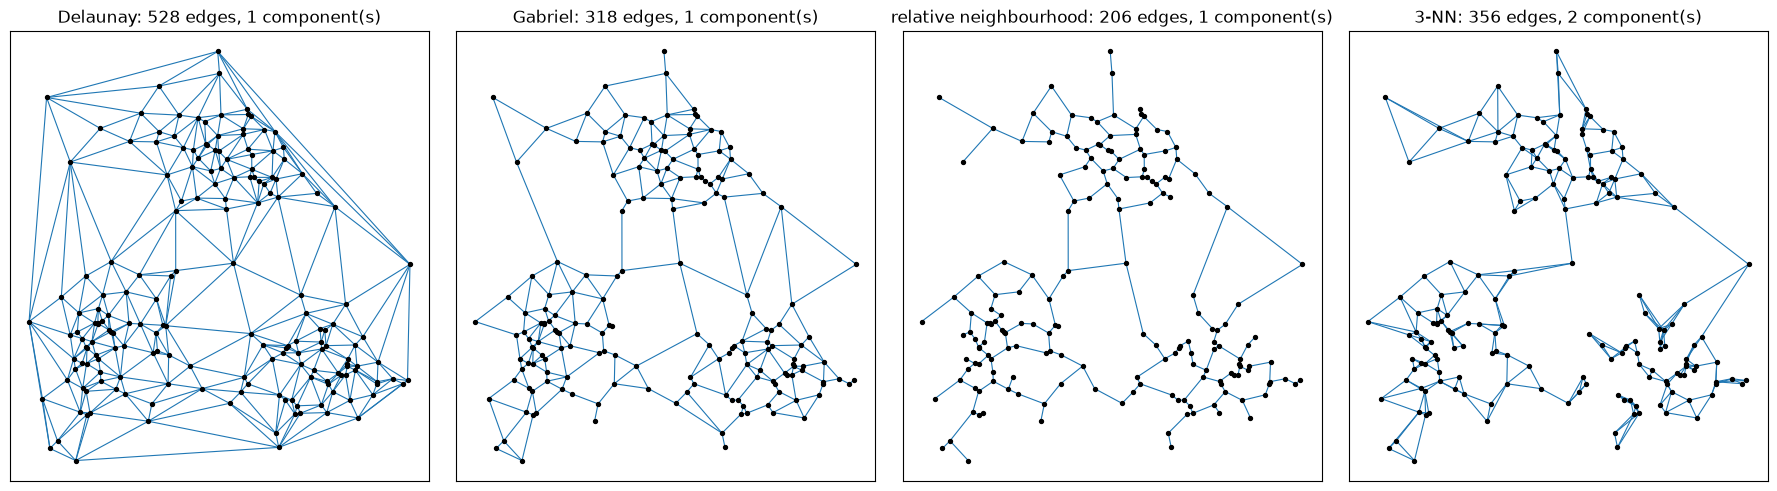

In [14]:
rng = np.random.default_rng(3)
centres = np.array([[0.2, 0.3], [0.75, 0.25], [0.5, 0.8]])
cluster_id = rng.integers(0, 3, 150)
sites = centres[cluster_id] + 0.09 * rng.normal(size=(150, 2))
sites = jnp.asarray(np.vstack([sites, rng.uniform(size=(30, 2))]))

graphs = {
    "Delaunay": kl.delaunay_graph(sites, weighting="connectivity"),
    "Gabriel": kl.gabriel_graph(sites, weighting="connectivity"),
    "relative neighbourhood": kl.relative_neighborhood_graph(
        sites, weighting="connectivity"
    ),
    "3-NN": kl.knn_graph(sites, 3, weighting="connectivity"),
}


def draw_edges(ax, graph, points, **kw):
    s, r = graph.topology.senders, graph.topology.receivers
    p = np.asarray(points)
    segments = einx.id("e c, e c -> e (1 + 1) c", p[s], p[r])
    ax.add_collection(LineCollection(segments, **kw))


fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
for ax, (name, graph) in zip(axes, graphs.items(), strict=True):
    draw_edges(ax, graph, sites, colors="C0", linewidths=0.8)
    ax.scatter(sites[:, 0], sites[:, 1], s=8, c="k", zorder=3)
    n_comp = kl.n_components_graph(graph)
    ax.set_title(f"{name}: {graph.topology.n_edges} edges, {n_comp} component(s)")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

### ICAR / Besag priors and the BYM2 scaling

The **intrinsic CAR (ICAR, Besag)** prior {cite:p}`besag1991bayesian` on a graph with edge weights $w_{ij}$ (here 1) has structure matrix $R = L$, the unnormalised Laplacian, and density

$$p(x \mid \tau) \propto \tau^{(N - c)/2} \exp\Big(-\frac\tau2 \sum_{i \sim j} w_{ij}\,(x_i - x_j)^2\Big) = \tau^{(N - c)/2} \exp\Big(-\frac\tau2\, x^\top R\, x\Big),$$

where $c$ is the number of connected components. $R$ is positive semidefinite with rank $N - c$. Its null space is spanned by the normalised component indicators $\mathbf 1_C / \sqrt{|C|}$, the columns of $V = $ `graph_null_space(graph)`, and the density is flat along it. The prior is proper only on the subspace $V^\top x = 0$: one sum-to-zero constraint per component {cite:p}`rue2005gmrf`. There the covariance is $\tau^{-1} R^{+}$, with $R^{+}$ the Moore–Penrose pseudo-inverse.

The marginal variances $[R^{+}]_{ii}$ depend on the graph, so a precision $\tau$ means something different on every graph. The **BYM2 scaling** {cite:p}`sorbye2014scaling,riebler2016bym2` fixes this by rescaling to geometric-mean marginal variance 1:

$$s = \exp\Big(\frac1N \sum_{i=1}^{N} \log\,[R^{+}]_{ii}\Big), \qquad R^\ast = s R, \qquad \exp\Big(\frac1N \sum_i \log\,[R^{\ast +}]_{ii}\Big) = 1.$$

`structure_matrix(graph, scaled=True)` returns $R^\ast$, scaling each connected component separately as R-INLA does (`gaussx.generalized_variance_scale` computes $s$); an isolated node has nothing to scale. It is a sparse gaussx operator (a `KroneckerSum` on a grid). In the BYM2 model the scaled ICAR effect $u^\ast$ is mixed with unstructured noise, $b = \sigma\big(\sqrt{1 - \phi}\, v + \sqrt{\phi}\, u^\ast\big)$ with $v \sim \mathcal N(0, I)$, so that $\phi$ is the share of the variance that is spatially structured.

In [15]:
gabriel = graphs["Gabriel"]
R = kl.structure_matrix(gabriel, scaled=True)
null = kl.graph_null_space(gabriel)
print(f"structure matrix: {type(R).__name__}, null space {null.shape}")

R_dense = R.as_matrix()
eigval, eigvec = jnp.linalg.eigh(R_dense)
keep = eigval > 1e-6 * eigval[-1]
basis = eigvec[:, keep]
cov = einx.dot(
    "n m, p m -> n p", einx.divide("n m, m -> n m", basis, eigval[keep]), basis
)
geo_mean = float(jnp.exp(jnp.mean(jnp.log(jnp.diag(cov)))))
print(
    f"zero eigenvalues: {int((~keep).sum())}; "
    f"geometric-mean marginal variance: {geo_mean:.4f}"
)

structure matrix: SparseOperator, null space (180, 1)


zero eigenvalues: 1; geometric-mean marginal variance: 1.0000


A k-NN graph with small $k$ shows the per-component constraints: each component gets its own column in the null space, and its own scaling.

In [16]:
knn3 = graphs["3-NN"]
null3 = kl.graph_null_space(knn3)
sizes = einx.sum("n c -> c", null3 > 0)
print(f"3-NN graph: null space {null3.shape}, component sizes {np.asarray(sizes)}")

3-NN graph: null space (180, 2), component sizes [172   8]


A constrained ICAR sample is $x = V_+ \Lambda_+^{-1/2} z$ over the non-null eigenpairs $(\Lambda_+, V_+)$ of $R^\ast$, with $z \sim \mathcal N(0, I_{N - c})$: it sums to zero, and neighbouring sites take similar values.

|null^T x| = 1.1e-13


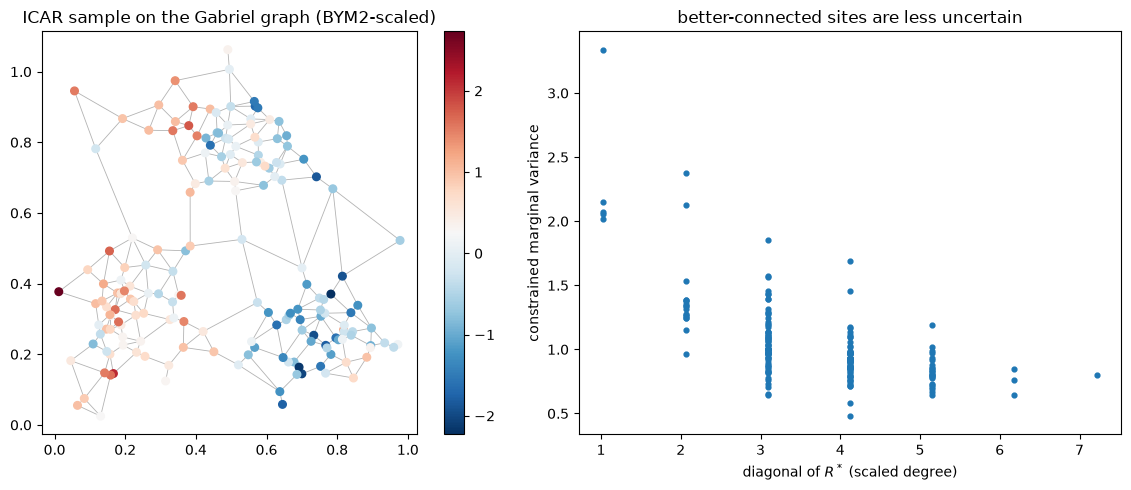

In [17]:
z_sites = jax.random.normal(jax.random.key(1), (int(keep.sum()),))
x_icar = eigvec[:, keep] @ (z_sites / jnp.sqrt(eigval[keep]))
print(f"|null^T x| = {float(jnp.abs(einx.dot('n c, n -> c', null, x_icar))[0]):.1e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
draw_edges(axes[0], gabriel, sites, colors="0.7", linewidths=0.6)
sc = axes[0].scatter(sites[:, 0], sites[:, 1], c=x_icar, s=30, cmap="RdBu_r", zorder=3)
plt.colorbar(sc, ax=axes[0])
axes[0].set_title("ICAR sample on the Gabriel graph (BYM2-scaled)")
axes[0].set_aspect("equal")
axes[1].scatter(jnp.diag(R_dense), jnp.diag(cov), s=12)
axes[1].set_xlabel("diagonal of $R^*$ (scaled degree)")
axes[1].set_ylabel("constrained marginal variance")
axes[1].set_title("better-connected sites are less uncertain")
plt.tight_layout()
plt.show()

### Cotangent weights and the SPDE link

A triangulation is also a finite-element mesh. With piecewise-linear (P1) hat functions $\psi_i$, the stiffness matrix $G_{ij} = \int \nabla\psi_i \cdot \nabla\psi_j$ has, for an edge $\{i, j\}$ with opposite angles $\alpha_{ij}$ and $\beta_{ij}$ (only $\alpha_{ij}$ on a boundary edge),

$$G_{ij} = -\tfrac12\big(\cot\alpha_{ij} + \cot\beta_{ij}\big), \qquad G_{ii} = -\sum_{j \ne i} G_{ij}$$

{cite:p}`pinkall1993cotangent`. So `mesh_graph(vertices, triangles, weighting="cotangent")`, with edge weights $w_{ij} = \tfrac12(\cot\alpha_{ij} + \cot\beta_{ij})$, has the stiffness matrix as its Laplacian, $L = G$.

This is the matrix behind SPDE priors on irregular meshes {cite:p}`lindgren2011spde`. The Matérn field solving $(\kappa^2 - \Delta)^{\alpha/2}(\tau x) = \mathcal W$, discretised with the lumped mass matrix $\tilde C = \operatorname{diag}(\int \psi_i)$, has the sparse precision

$$Q_1 = \tau^2\big(\kappa^2 \tilde C + G\big) \;(\alpha = 1), \qquad Q_2 = \tau^2\big(\kappa^4 \tilde C + 2\kappa^2 G + G \tilde C^{-1} G\big) \;(\alpha = 2).$$

Replacing $\tilde C$ by $I$ and $G$ by a graph Laplacian $L$ gives $\tau^2(\kappa^2 I + L)^\alpha$, the precision of the graph Matérn prior of section 2 with $\nu = \alpha$ and $\kappa^2 = 2\nu/\ell^2$ (that is, `lengthscale = sqrt(2 * alpha) / kappa`).

A weight is negative when $\alpha_{ij} + \beta_{ij} > \pi$ on an interior edge, or $\alpha_{ij} > \pi/2$ on a boundary edge. Then $G$ is still positive semidefinite but no longer a graph Laplacian with non-negative weights, and by default `mesh_graph` raises rather than clamp the weight. On the Delaunay triangulation of the scattered sites above it raises: every Delaunay interior edge has $\alpha_{ij} + \beta_{ij} \le \pi$, but some convex-hull triangles have an obtuse angle facing a boundary edge, which has no second triangle to compensate. The error names that boundary case apart from a non-Delaunay interior edge, and `on_negative="clip"` (set such weights to 0) or `on_negative="allow"` (keep the signed stiffness $G$) accepts the mesh. A signed graph supports only the unnormalised Laplacian $L = G$ (`laplacian_operator()`, `structure_matrix`, `dirichlet_energy`): the symmetric Laplacian, and the eigenmaps under their default degree constraint $L y = \lambda D y$, raise a `ValueError` on negative weights, because $D$ need not be positive; `constraint="identity"` accepts them. The mesh below avoids negative weights altogether. It is a jittered triangular lattice: its triangles are close to equilateral, no angle reaches 90°, and every weight is positive.

mesh: 144 vertices, 242 triangles, 385 edges
max |stiffness @ 1| = 4.4e-16
cotangent weights: min 0.143, median 0.567, max 0.933


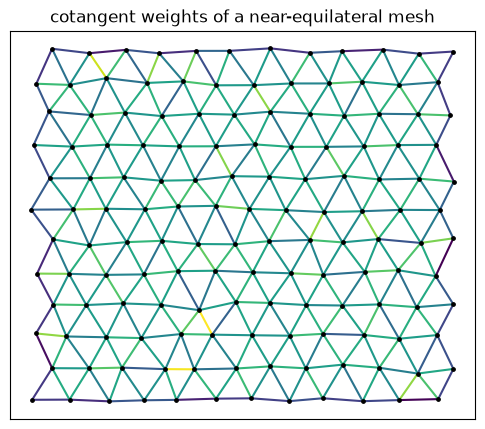

In [18]:
n_mesh = 12
row, col = np.mgrid[0:n_mesh, 0:n_mesh].astype(float)
lattice_xy = np.stack([col + 0.5 * (row % 2), row * np.sqrt(3) / 2]) / (n_mesh - 1)
jitter = 0.05 / (n_mesh - 1) * np.random.default_rng(4).normal(size=lattice_xy.shape)
vertices = jnp.asarray(einx.id("c h w -> (h w) c", lattice_xy + jitter))
node = einx.id("(h w) -> h w", np.arange(n_mesh * n_mesh), h=n_mesh)
triangles = []
for j in range(n_mesh - 1):
    for i in range(n_mesh - 1):
        p, q = node[j, i], node[j, i + 1]  # this row
        r, t = node[j + 1, i], node[j + 1, i + 1]  # the row above
        triangles += [(p, q, r), (q, t, r)] if j % 2 == 0 else [(p, t, r), (p, q, t)]
triangles = np.array(triangles)

mesh = kl.mesh_graph(vertices, triangles, weighting="cotangent")
stiffness = mesh.laplacian_operator()
row_sums = stiffness.mv(jnp.ones(mesh.n_nodes))
w = np.asarray(mesh.weights)
print(
    f"mesh: {mesh.n_nodes} vertices, {len(triangles)} triangles, "
    f"{mesh.topology.n_edges} edges"
)
print(f"max |stiffness @ 1| = {float(jnp.max(jnp.abs(row_sums))):.1e}")
print(
    f"cotangent weights: min {w.min():.3f}, median {np.median(w):.3f}, "
    f"max {w.max():.3f}"
)

fig, ax = plt.subplots(figsize=(6, 6))
draw_edges(ax, mesh, vertices, array=w, cmap="viridis", linewidths=1.5)
ax.scatter(vertices[:, 0], vertices[:, 1], s=6, c="k", zorder=3)
ax.set_title("cotangent weights of a near-equilateral mesh")
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

**Numerics.** The proximity builders and `mesh_graph` run eagerly on the host: Qhull needs concrete points in general position, and duplicate or all-collinear points raise. The edge weights are JAX arrays, differentiable in a heat bandwidth or in the vertex coordinates. The ICAR cells above use a dense pseudo-inverse, dropping eigenvalues below $10^{-6}$ times the largest as the null space; that is only for illustration at $N = 180$. At scale the structure matrix stays sparse, and gaussx's sparse Cholesky with the null-space constraints gives log-determinants, samples and (by selected inversion) marginal variances without a dense matrix.

## 4. Spatial-spectral embeddings of images

Lattices and spectral data meet in hyperspectral images. Laplacian eigenmaps {cite:p}`belkin2003eigenmaps` embed the pixels by the smallest solutions of $L y = \lambda D y$ on a graph of their spectra. Schrödinger eigenmaps {cite:p}`czaja2013schrodinger` add a potential $V \succeq 0$, solving $(L + \alpha V)\,y = \lambda D y$. Weighting the pixel lattice by spectral similarity gives the spatial-spectral graph of {cite:t}`cahill2014spatialspectral`, whose Laplacian is a potential that pulls together pixels that are adjacent *and* alike:

```python
X = einx.id("h w b -> (h w) b", cube)
spectral = kl.knn_graph(X, 10)                                # spectra only
V = kl.spatial_spectral_graph(X, kl.grid_graph(cube.shape[:2])).laplacian_operator()
se = kl.SchrodingerEigenmaps(n_components=4, alpha=10.0, eigen_solver="arpack")
Y = se.fit(X, V, graph=spectral).embedding                    # sparse throughout
```

The [spatial-spectral Schrödinger eigenmaps](spatial_spectral_eigenmaps.ipynb) notebook states the optimisation problems, the potential's weights and the trace normalisation in full. It runs this pipeline on a synthetic hyperspectral cube with two spectrally near-identical regions, compares it with Laplacian eigenmaps by k-means ARI, sweeps $\alpha$ with and without the normalisation, and scales it up with approximate neighbours.

## Summary

- A face-connected `GridGraph` has Kronecker-structured Laplacian eigenpairs: `laplacian_eigpairs` returns the smallest ones of a $10^6$-pixel raster from the closed-form eigenpairs of the two path factors, with no eigensolver and no $N \times N$ matrix, and keeps full relative precision in float32.
- The graph Matérn kernel is a spectral function of the Laplacian. `matern_graph_kernel` gives the dense kernel; `laplacian_eigpairs` plus `graph_matern_spectrum` gives the same prior, and its truncation for large graphs, where `method="lanczos"` (residual-checked; it raises rather than return wrong eigenpairs) or `"arpack"` supplies the eigenpairs.
- Delaunay, Gabriel and relative neighbourhood graphs are connected and parameter-free; `structure_matrix` turns any graph into a (BYM2-scaled) ICAR structure, with `graph_null_space` supplying one sum-to-zero constraint per component, and `mesh_graph` gives the FEM stiffness matrix of a triangle mesh (`on_negative` decides what happens to negative cotangent weights).